# 14 · Las aristas que se pierden son las que no se dibujan

El notebook 07 descompuso el error de aristas por **causa mecánica** (falta un nodo, falta
el retorno, sin conexión). Este lo parte por una dimensión distinta: **el tipo de arista
que el propio Cloudscape declara**.

Cloudscape distingue dos clases (§2.2 del paper de Satija et al.):

| tipo | definición de los autores |
|---|---|
| `data` | *"indicate movement of user data"* |
| `meta` | *"do not carry data but indicate a request trigger or an acknowledgment response"* |

Un *trigger* o un *ack* es justamente lo que un presentador **enuncia** en vez de
**dibujar**. Si el déficit topológico se concentra ahí, la explicación de RQ3 pasa de
«la narración lleva aristas» a «**estas** aristas viven en la narración», con la
taxonomía del propio dataset como respaldo.

## La trampa que hay que evitar

La versión ingenua de esta medición —partir *nuestras* aristas por *nuestro* campo
`type`— **no es válida**, y la celda 2 muestra por qué: nuestro pipeline emite un
vocabulario que no es el de Cloudscape.

La medición que sí vale nunca lee nuestras etiquetas. Toma las aristas **del ground
truth**, las parte por **su propio** tipo, y pregunta *¿produjimos ese par de servicios,
sí o no?*. El emparejamiento es sobre `(servicio_origen, servicio_destino)` y nada más.
Por eso este notebook reporta **recall y no F1**: la precisión por subgrupo exigiría
confiar en nuestras etiquetas, y no se puede.

In [1]:
import collections
import os
import xml.etree.ElementTree as ET
from math import comb
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

GT_DIR = Path("../data/cloudscape_gt")
ARMS = {"Standard": Path("../data/graphs"),
        "Parsimonious": Path("../data/graphs_parsimonious")}
RUNS = Path("../reports/runs")
NS = {"g": "http://graphml.graphdrawing.org/xmlns"}
pd.set_option("display.width", 200)

# El panel es el mismo de los notebooks 05 y 07: los videos que los DOS pipelines
# marcaron como usables. Se define desde los results.csv y no desde el disco, para que
# este notebook no invente una muestra propia.
S = pd.read_csv(RUNS / "2026-08-20_standard_v6corrected_370v/results.csv")
P = pd.read_csv(RUNS / "2026-08-21_parsimonious_v9/results.csv")
M = S.merge(P, on="video_id", suffixes=("_s", "_p"))
VIDS = sorted(M[(M.graph_usable_s == True) & (M.graph_usable_p == True)].video_id)
print(f"panel pareado: n = {len(VIDS)}")


def leer(path: Path):
    """Devuelve (servicios_por_nodo, [((svc_origen, svc_destino), tipo), ...])."""
    root = ET.parse(path).getroot()
    keys = {k.get("id"): k.get("attr.name") for k in root.findall("g:key", NS)}

    def attr(el, nombre):
        for d in el.findall("g:data", NS):
            if keys.get(d.get("key")) == nombre:
                return (d.text or "").strip()
        return ""

    svc = {n.get("id"): attr(n, "service")
           for n in root.iter("{http://graphml.graphdrawing.org/xmlns}node")}
    edges = [((svc.get(e.get("source"), "?"), svc.get(e.get("target"), "?")), attr(e, "type"))
             for e in root.iter("{http://graphml.graphdrawing.org/xmlns}edge")]
    return list(svc.values()), edges


GT = {v: leer(GT_DIR / f"{v}.graphml") for v in VIDS}
GEN = {a: {v: leer(d / f"{v}.graphml") for v in VIDS if (d / f"{v}.graphml").exists()}
       for a, d in ARMS.items()}
for a, g in GEN.items():
    print(f"  {a:14s} {len(g)} grafos leídos")

panel pareado: n = 321
  Standard       321 grafos leídos
  Parsimonious   321 grafos leídos


### Compuerta: ¿estos grafos son los que produjeron las cifras del paper?

Todo lo que sigue se calcula desde los `.graphml` en disco, no desde los `results.csv`.
Antes de creerle a una sola cifra hay que verificar que esos archivos son los mismos que
generaron los números publicados. Se recalcula el Service F1 de conjunto y tiene que dar
**86.78** y **85.73** exactos.

In [2]:
def f1(gen: collections.Counter, gt: collections.Counter) -> float:
    inter = sum((gen & gt).values())
    p = inter / sum(gen.values()) if sum(gen.values()) else 0.0
    r = inter / sum(gt.values()) if sum(gt.values()) else 0.0
    return 2 * p * r / (p + r) if p + r else 0.0


REF = {"Standard": 86.78, "Parsimonious": 85.73}
for arm in ARMS:
    vals = [f1(collections.Counter(set(GEN[arm][v][0])), collections.Counter(set(GT[v][0])))
            for v in GEN[arm]]
    got = 100 * np.mean(vals)
    ok = abs(got - REF[arm]) < 0.005
    print(f"  {arm:14s} Service F1 (conjunto) = {got:.2f}   esperado {REF[arm]}   "
          f"{'OK' if ok else 'DESAJUSTE'}")
    assert ok, f"{arm}: los graphml en disco no reproducen la cifra publicada"
print("\nCompuerta pasada: los graphml en disco son los que produjeron el paper.")

  Standard       Service F1 (conjunto) = 86.78   esperado 86.78   OK
  Parsimonious   Service F1 (conjunto) = 85.73   esperado 85.73   OK

Compuerta pasada: los graphml en disco son los que produjeron el paper.


## 1 · Nuestro `type` no es el `type` de Cloudscape

Primero, la razón por la que la versión ingenua de este análisis no sirve.

In [3]:
def vocab(edges_por_video) -> pd.Series:
    c = collections.Counter(t or "(vacío)" for _, es in edges_por_video.items() for _, t in es[1])
    return pd.Series(c).sort_values(ascending=False)


# Ojo: construir el DataFrame columna por columna alinearía cada brazo contra el índice
# del ground truth y borraría en silencio justamente las etiquetas ajenas que se buscan.
# El concat conserva la unión de los índices, que es el punto de esta tabla.
voc = pd.concat([vocab(GT).rename("Ground truth")] +
                [vocab(GEN[a]).rename(a) for a in ARMS], axis=1).fillna(0).astype(int)
pct = (100 * voc / voc.sum()).round(1)
display(pd.concat({"aristas": voc, "%": pct}, axis=1))

fuera = sorted(set(voc.index) - {"data", "meta"})
print(f"\nEtiquetas que el ground truth NUNCA usa: {fuera}")
for arm in ARMS:
    n_fuera = int(voc.loc[[e for e in fuera if e in voc.index], arm].sum())
    print(f"  {arm:14s} {n_fuera:5d} aristas con etiqueta ajena "
          f"({100 * n_fuera / voc[arm].sum():.1f} % de las suyas)")

aristas                                  %                      
              Ground truth Standard Parsimonious Ground truth Standard Parsimonious
data                  3223     1910         2563         80.8     65.8         90.5
meta                   764      130           73         19.2      4.5          2.6
control                  0      861            0          0.0     29.7          0.0
data_flow                0        0          149          0.0      0.0          5.3
triggers                 0        0           23          0.0      0.0          0.8
writes_to                0        0           18          0.0      0.0          0.6
reads_from               0        0            4          0.0      0.0          0.1
network                  0        0            2          0.0      0.0          0.1
authenticates            0        0            1          0.0      0.0          0.0


Etiquetas que el ground truth NUNCA usa: ['authenticates', 'control', 'data_flow', 'network', 'reads_from', 'triggers', 'writes_to']
  Standard         861 aristas con etiqueta ajena (29.7 % de las suyas)
  Parsimonious     197 aristas con etiqueta ajena (7.0 % de las suyas)


Standard emite **`control`**, que no existe en el vocabulario de Cloudscape, y
Parsimonious emite media docena de etiquetas propias (`data_flow`, `triggers`,
`writes_to`, …). No es que clasifiquemos mal `data` contra `meta`: **estamos usando otro
vocabulario**.

Cualquier análisis que parta nuestras aristas por nuestro `type` mediría una
correspondencia que no existe. De acá en adelante ese campo no se vuelve a leer.

## 2 · Recall de las aristas del GT, partido por el tipo **del GT**

Para cada video se toman las aristas del ground truth agrupadas por su tipo, y se cuenta
cuántas aparecen entre los pares de servicios que produjo el pipeline. El emparejamiento
es por multiconjunto sobre `(origen, destino)` — el mismo criterio de la evaluación
estricta, sin ninguna condición sobre el tipo.

**Ambigüedad de asignación.** Un mismo par `(a, b)` puede figurar en el GT como `data` y
como `meta` a la vez. Cuando eso pasa no hay forma de saber a cuál de los dos corresponde
la arista que generamos, así que el crédito se reparte en proporción a los conteos del GT.
Se reporta cuántas aristas quedaron en esa situación para que el lector juzgue si el
reparto puede mover el resultado.

In [4]:
def recall_por_tipo(arm: str):
    """Devuelve (agregado, por_video). Nunca lee el campo `type` de nuestros grafos."""
    tot = {"data": 0.0, "meta": 0.0}
    hit = {"data": 0.0, "meta": 0.0}
    ambiguas = 0
    filas = []
    for v, (_, gen_edges) in GEN[arm].items():
        gen = collections.Counter(par for par, _ in gen_edges)
        gt = {t: collections.Counter(par for par, tt in GT[v][1] if tt == t)
              for t in ("data", "meta")}
        h = {"data": 0.0, "meta": 0.0}
        n = {t: sum(gt[t].values()) for t in gt}
        for par in set(gt["data"]) | set(gt["meta"]):
            a, b, g = gt["data"][par], gt["meta"][par], gen[par]
            enc = min(g, a + b)
            if a and b:
                ambiguas += enc
            if enc:                       # reparto proporcional del crédito
                h["data"] += enc * a / (a + b)
                h["meta"] += enc * b / (a + b)
        for t in ("data", "meta"):
            tot[t] += n[t]
            hit[t] += h[t]
        if n["data"] and n["meta"]:       # sólo videos con ambos tipos entran al pareado
            filas.append({"video_id": v,
                          "recall_data": 100 * h["data"] / n["data"],
                          "recall_meta": 100 * h["meta"] / n["meta"]})
    agg = {t: 100 * hit[t] / tot[t] for t in tot}
    return agg, tot, ambiguas, pd.DataFrame(filas)


RES = {}
tabla = []
for arm in ARMS:
    agg, tot, amb, df = recall_por_tipo(arm)
    RES[arm] = df
    tabla.append({"brazo": arm,
                  "aristas data (GT)": int(tot["data"]), "recall data": round(agg["data"], 2),
                  "aristas meta (GT)": int(tot["meta"]), "recall meta": round(agg["meta"], 2),
                  "brecha": round(agg["data"] - agg["meta"], 2),
                  "ambiguas": amb})
T = pd.DataFrame(tabla).set_index("brazo")
display(T)

amb_pct = 100 * T["ambiguas"].max() / (T["aristas data (GT)"].iloc[0] + T["aristas meta (GT)"].iloc[0])
print(f"\nLas aristas ambiguas (mismo par como data y meta) son a lo sumo {amb_pct:.1f} % "
      f"del total del GT:\nel reparto proporcional no puede explicar una brecha de "
      f"{T['brecha'].min():.0f} puntos.")

,aristas data (GT),recall data,aristas meta (GT),recall meta,brecha,ambiguas
brazo,,,,,,
Standard,3223,56.73,764,29.29,27.44,129
Parsimonious,3223,54.17,764,26.73,27.43,124



Las aristas ambiguas (mismo par como data y meta) son a lo sumo 3.2 % del total del GT:
el reparto proporcional no puede explicar una brecha de 27 puntos.


Las aristas `meta` se recuperan a **poco más de la mitad** de la tasa de las `data`, y la
brecha es prácticamente idéntica en los dos pipelines. Como Standard y Parsimonious son
diseños de prompt distintos, corridos por separado, eso es una **réplica independiente**
del hallazgo y no una peculiaridad de un prompt.

## 3 · ¿Sobrevive a una prueba pareada por video?

El agregado pondera por cantidad de aristas y podría estar dominado por unos pocos videos
con muchas `meta`. La prueba pareada elimina esa objeción: para cada video que tiene
aristas de los dos tipos se comparan sus dos recalls.

Se usa el **test de signos exacto**, que no supone ninguna distribución — coherente con el
criterio del notebook 01 de no apoyarse en normalidad cuando no hace falta.

In [5]:
def signos(dif: np.ndarray) -> tuple[int, int, int, float]:
    pos = int((dif > 0).sum())
    neg = int((dif < 0).sum())
    n = pos + neg
    if n == 0:
        return pos, neg, 0, 1.0
    k = max(pos, neg)
    p = min(1.0, 2 * sum(comb(n, i) for i in range(k, n + 1)) / 2 ** n)
    return pos, neg, int((dif == 0).sum()), p


for arm in ARMS:
    df = RES[arm]
    d = (df.recall_data - df.recall_meta).to_numpy()
    pos, neg, emp, p = signos(d)
    print(f"{arm:14s} videos con ambos tipos: {len(df):3d} | "
          f"data > meta {pos:3d} / data < meta {neg:3d} / empates {emp}")
    print(f"{'':14s} mediana de la diferencia: {np.median(d):+6.2f} pts | "
          f"test de signos p = {p:.3g}\n")

Standard       videos con ambos tipos: 196 | data > meta 150 / data < meta  46 / empates 0
               mediana de la diferencia: +34.58 pts | test de signos p = 4.6e-14

Parsimonious   videos con ambos tipos: 196 | data > meta 150 / data < meta  44 / empates 2
               mediana de la diferencia: +35.67 pts | test de signos p = 9.79e-15



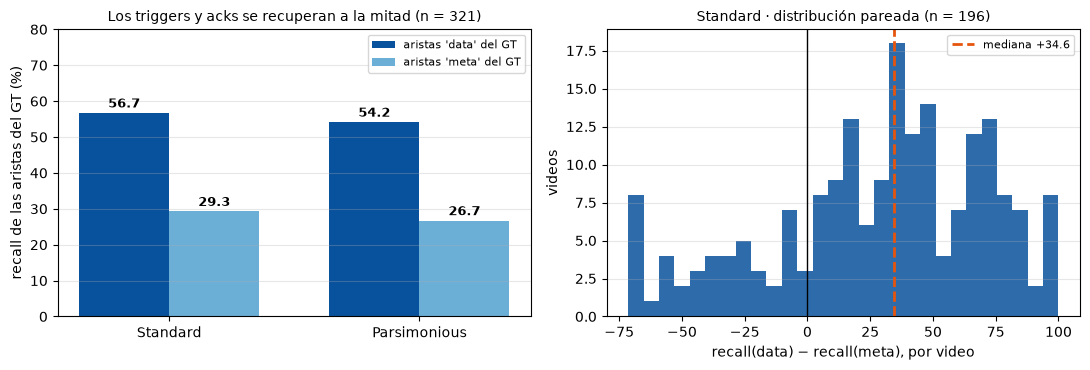

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

ax = axes[0]
x = np.arange(len(ARMS)); w = .36
d_vals = [T.loc[a, "recall data"] for a in ARMS]
m_vals = [T.loc[a, "recall meta"] for a in ARMS]
ax.bar(x - w/2, d_vals, w, label="aristas 'data' del GT", color="#08519c")
ax.bar(x + w/2, m_vals, w, label="aristas 'meta' del GT", color="#6baed6")
for i, (a, b) in enumerate(zip(d_vals, m_vals)):
    ax.text(i - w/2, a + 1.5, f"{a:.1f}", ha="center", fontsize=9, fontweight="bold")
    ax.text(i + w/2, b + 1.5, f"{b:.1f}", ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(list(ARMS)); ax.set_ylim(0, 80)
ax.set_ylabel("recall de las aristas del GT (%)")
ax.set_title(f"Los triggers y acks se recuperan a la mitad (n = {len(VIDS)})", fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=.3, axis="y")

ax = axes[1]
d = (RES["Standard"].recall_data - RES["Standard"].recall_meta).to_numpy()
ax.hist(d, bins=28, color="#08519c", alpha=.85)
ax.axvline(0, color="k", lw=1)
ax.axvline(np.median(d), color="#e6550d", lw=2, ls="--",
           label=f"mediana {np.median(d):+.1f}")
ax.set_xlabel("recall(data) − recall(meta), por video")
ax.set_ylabel("videos")
ax.set_title(f"Standard · distribución pareada (n = {len(d)})", fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=.3, axis="y")

plt.tight_layout(); plt.show()

## 4 · Qué tan sólido es esto

### La objeción real: Cloudscape no publica reglas para `data` vs `meta`

Toda la definición que dan los autores es la oración citada arriba. No hay procedimiento
de decisión, no hay ejemplos de casos difíciles, y el proceso de anotación (§2.2: tres
personas sobre 50 arquitecturas, iteración, luego tres más entrenadas y "verified and
discussed") **no reporta ninguna métrica de acuerdo inter-anotador**. La confiabilidad de
la etiqueta `meta` es desconocida.

### Por qué el resultado sobrevive de todos modos

Si la etiqueta fuera ruidosa **de forma independiente** de si recuperamos la arista, los
dos subgrupos serían mezclas el uno del otro y la brecha se encogería hacia cero.
Etiquetas al azar ⇒ misma composición ⇒ mismo recall ⇒ brecha nula. El ruido de etiqueta
puede **esconder** una brecha; no puede fabricarla. Encontrar ~27 puntos pese a una
confiabilidad desconocida implica que la brecha real es **al menos** esa.

### El confound que sí hay que declarar

Ese argumento supone que el error de etiqueta no correlaciona con la recuperabilidad, y
puede que sí correlacione: si el anotador tendió a marcar `meta` justamente cuando la
arista sólo se mencionaba de palabra y no estaba dibujada, entonces la etiqueta y nuestro
fallo comparten causa y la brecha está inflada.

Conviene ver que ese confound **cuenta la misma historia causal** —las aristas que se
pierden son las que viven en la narración—. Lo que queda en duda no es el hallazgo sino si
`meta` es el nombre correcto para ese conjunto.

### Lo que se puede y lo que no se puede afirmar

| | |
|---|---|
| ✅ | El déficit topológico **no es uniforme**: se concentra en la clase de aristas que el propio dataset define como triggers y acknowledgments. |
| ✅ | El efecto **replica en dos pipelines independientes** con brechas que difieren en menos de 0.1 pts. |
| ❌ | *"Nuestro pipeline no distingue data de meta"* — no se midió, y no se puede medir: usamos otro vocabulario. |
| ❌ | Precisión o F1 por subgrupo. Sólo recall, porque la precisión exigiría confiar en nuestras etiquetas. |

## 5 · Efecto colateral: `edge_type_accuracy` es una métrica rota

La evaluación estándar reporta `edge_type_accuracy` — de las aristas acertadas como par de
servicios, qué fracción también acertó el tipo. Con vocabularios distintos esa métrica no
mide lo que dice medir: **premia parecerse a la distribución del ground truth**.

In [7]:
def type_accuracy(arm: str) -> float:
    """Reimplementa evaluate_graphs.edge_type_accuracy: de las aristas acertadas como par
    de servicios, qué fracción acertó además el tipo. Se recalcula acá porque el CSV de
    Parsimonious ni siquiera trae la columna."""
    vals = []
    for v, (_, gen_edges) in GEN[arm].items():
        gt_edges = GT[v][1]
        con_tipo = sum((collections.Counter((a, b, t) for (a, b), t in gen_edges) &
                        collections.Counter((a, b, t) for (a, b), t in gt_edges)).values())
        sin_tipo = sum((collections.Counter(p for p, _ in gen_edges) &
                        collections.Counter(p for p, _ in gt_edges)).values())
        vals.append(con_tipo / sin_tipo if sin_tipo else 0.0)
    return 100 * float(np.mean(vals))


filas = []
for arm in ARMS:
    c = vocab(GEN[arm])
    filas.append({"brazo": arm,
                  "% etiquetado 'data'": round(100 * c.get("data", 0) / c.sum(), 1),
                  "etiquetas distintas": int((c > 0).sum()),
                  "edge_type_accuracy": round(type_accuracy(arm), 2)})
E = pd.DataFrame(filas).set_index("brazo")
display(E)

base = 100 * vocab(GT).get("data", 0) / vocab(GT).sum()
print(f"tasa base del ground truth ('data'): {base:.1f} %")

# Compuerta: la reimplementación tiene que dar lo que ya reportaba el CSV de Standard.
# La columna del results.csv ya viene en escala 0-100, igual que svc_f1: no multiplicar.
ref = M.set_index("video_id").loc[VIDS, "edge_type_accuracy"].mean()
print(f"compuerta · Standard recalculado {type_accuracy('Standard'):.2f} vs "
      f"results.csv {ref:.2f}\n")

print("Parsimonious puntúa más alto no por tipar mejor, sino porque etiqueta 'data' en una\n"
      "proporción más cercana a la tasa base del GT. Standard emite 'control' en ~30 % de\n"
      "sus aristas y esa etiqueta no puede coincidir nunca.\n"
      "La métrica no es interpretable como acierto de tipo: hay que sacarla o redefinirla\n"
      "contra un vocabulario mapeado.")

,% etiquetado 'data',etiquetas distintas,edge_type_accuracy
brazo,,,
Standard,65.8,3,61.51
Parsimonious,90.5,8,83.59


tasa base del ground truth ('data'): 80.8 %
compuerta · Standard recalculado 61.51 vs results.csv 61.51

Parsimonious puntúa más alto no por tipar mejor, sino porque etiqueta 'data' en una
proporción más cercana a la tasa base del GT. Standard emite 'control' en ~30 % de
sus aristas y esa etiqueta no puede coincidir nunca.
La métrica no es interpretable como acierto de tipo: hay que sacarla o redefinirla
contra un vocabulario mapeado.


## 6 · Nodos duplicados: el GT los conserva a propósito

Cloudscape mantiene nodos duplicados cuando un servicio aparece varias veces en el video
(§2.2: *"we keep duplicate nodes if they appear multiple times"* — el ejemplo de Snap en su
Figura 2a tiene EKS1…EKS4). La multiplicidad es información deliberada del ground truth.

El Service F1 que reporta el paper es el **de conjunto**, que colapsa EKS1…EKS4 en un solo
`EKS`. No está mal, pero mide un objeto más grueso que el que el GT codifica, y conviene
reportar las dos versiones para que un revisor no tenga que preguntarlo.

In [8]:
filas = []
for arm in ARMS:
    cj, ms = [], []
    for v in GEN[arm]:
        g, t = GEN[arm][v][0], GT[v][0]
        cj.append(f1(collections.Counter(set(g)), collections.Counter(set(t))))
        ms.append(f1(collections.Counter(g), collections.Counter(t)))
    filas.append({"brazo": arm,
                  "Service F1 (conjunto)": round(100 * np.mean(cj), 2),
                  "Service F1 (multiconjunto)": round(100 * np.mean(ms), 2),
                  "Δ": round(100 * (np.mean(ms) - np.mean(cj)), 2)})
D = pd.DataFrame(filas).set_index("brazo")
display(D)

print("Contar la multiplicidad cuesta ~2 puntos en los dos brazos.\n\n"
      "Cuál reportar depende de la pregunta, y el paper debe decirlo:\n"
      "  · de CONJUNTO para RQ1 ('qué servicios se usan') y para RQ5, porque la\n"
      "    clasificación HPC/edge de Santillán y Abad opera sobre conjuntos de servicios;\n"
      "  · de MULTICONJUNTO para la pregunta distinta de si se reproduce el grafo completo.")

,Service F1 (conjunto),Service F1 (multiconjunto),Δ
brazo,,,
Standard,86.78,84.50,-2.28
Parsimonious,85.73,83.85,-1.88


Contar la multiplicidad cuesta ~2 puntos en los dos brazos.

Cuál reportar depende de la pregunta, y el paper debe decirlo:
  · de CONJUNTO para RQ1 ('qué servicios se usan') y para RQ5, porque la
    clasificación HPC/edge de Santillán y Abad opera sobre conjuntos de servicios;
  · de MULTICONJUNTO para la pregunta distinta de si se reproduce el grafo completo.


## Resumen

1. Nuestro campo `type` **no es comparable** con el de Cloudscape: Standard emite `control`
   (~30 % de sus aristas) y Parsimonious media docena de etiquetas propias. Cualquier
   análisis que lo use es inválido.
2. Partiendo por el tipo **del ground truth** y midiendo sólo recall, las aristas `meta`
   —triggers y acknowledgments— se recuperan a poco más de la mitad de la tasa de las
   `data`. La brecha replica en los dos pipelines con menos de 0.1 pts de diferencia y
   sobrevive a una prueba de signos pareada por video.
3. Eso precisa la conclusión de RQ3: lo que falta no es «topología» en general, sino la
   clase de aristas que un presentador enuncia en vez de dibujar — consistente con que el
   propio Cloudscape defina el ground truth como *"when the verbal description does not
   match what they drew, we consider the verbal description as the ground truth"*.
4. `edge_type_accuracy` está rota y hay que sacarla o redefinirla.
5. El Service F1 de conjunto y el de multiconjunto difieren en ~2 puntos; el paper debe
   reportar los dos y decir cuál responde a qué pregunta.

**Limitaciones declaradas:** Cloudscape no publica reglas de decisión ni acuerdo
inter-anotador para `data`/`meta`; y la etiqueta podría correlacionar con la visibilidad
de la arista en la pizarra, lo que inflaría la brecha sin cambiar la conclusión causal.